# Saudi Tadawul Beta Analysis

This notebook estimates the **market beta** of a curated set of Saudi Exchange (Tadawul) stocks by regressing each stock's monthly returns against the Tadawul All Share Index (TASI).

---

### What is Beta?

Beta (β) is the slope of a simple linear regression: **Stock Return ~ TASI Return**.
It measures how sensitive a stock is to overall market movements.

| Beta | Interpretation | Typical sectors |
|------|---------------|-----------------|
| > 1 | More volatile than the market — amplifies gains **and** losses | Consumer Discretionary, Materials |
| = 1 | Moves in line with the market | — |
| 0 – 1 | Less volatile — defensive | Utilities, Consumer Staples |
| < 0 | Moves **opposite** to the market (rare) | Certain hedging instruments |

> **Why does beta matter?** In the Capital Asset Pricing Model (CAPM), beta is the key risk measure. Higher-beta stocks demand a higher expected return as compensation for taking on more market risk.

---

### Workflow

| Section | What we do |
|---------|------------|
| 1 | Import libraries |
| 2 | Define the Saudi stock universe (~40 Tadawul-listed companies) |
| 3 | Download 5 years of adjusted close prices from Yahoo Finance |
| 4 | Convert daily prices → monthly returns |
| 5 | Examine Aramco's total market cap vs. free-float index weight |
| 6 | Define the CAPM regression function (alpha, beta, R², residual SE) |
| 7 | Run OLS for all stocks in one `.apply()` call |
| 8 | Visualise beta distributions by Tadawul sector (boxplot) |
| 9 | Summary statistics by sector |
| 10 | Most and least volatile individual stocks |
| 11 | Full beta histogram |
| 12 | Extension: 24-month rolling beta |
| 13 | Extension: Market-cap weighted index ex-Aramco |
| 14 | Extension: Cross-market beta vs. Brent crude |

### Learning Objectives

By the end of this notebook you will be able to:

1. **Apply CAPM to any market** — the same alpha/beta/R² framework works for Saudi stocks as for US stocks; only the benchmark and ticker format change.
2. **Distinguish total market cap from free-float index weight** — Aramco's ~98% government ownership means its total market cap dominance does not translate into equivalent TASI weight, which is why its beta is ~0.55, not ~1.
3. **Read Tadawul ticker codes** — numeric + `.SR` format; sector classification follows Tadawul conventions, not GICS.
4. **Use rolling beta to detect regime changes** — a static 5-year beta masks periods when a stock's market sensitivity was structurally different.
5. **Test sensitivity to benchmark choice** — comparing TASI betas to a market-cap weighted index ex-Aramco isolates the pure effect of one company's presence in the benchmark.
6. **Decompose risk factors** — cross-market beta against Brent crude separates oil-price sensitivity from Saudi domestic-market sensitivity.

---

## 1. Import Libraries

| Library | Role |
|---------|------|
| `pandas` | Core data manipulation: DataFrames, resampling, groupby |
| `datetime` | Creates date objects for defining our 5-year download window |
| `yfinance` | Unofficial Yahoo Finance wrapper — downloads historical price data |
| `numpy` | Fast numerical operations (sqrt, NaN handling) |
| `matplotlib` | Base plotting engine |
| `seaborn` | Higher-level statistical charts built on top of matplotlib |
| `statsmodels` | OLS regression with R-style formula syntax |
| `time` | Measures how long the regressions take |

In [62]:
# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd                    # DataFrames -- the core data manipulation tool
from datetime import date              # Date objects for defining our time window

# ── Finance data ──────────────────────────────────────────────────────────────
import yfinance as yf                  # Yahoo Finance API wrapper for historical price data

# ── Numerical & statistical ───────────────────────────────────────────────────
import numpy as np                     # Numerical operations (sqrt, nan handling)
import statsmodels.formula.api as smf  # OLS regression with R-style formula syntax

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # Base plotting library
import matplotlib.patches as mpatches  # Used for custom legend entries
import seaborn as sns                  # High-level statistical visualisations

# ── Utilities ─────────────────────────────────────────────────────────────────
import time                            # Timer to measure how long the regressions take

print("Libraries loaded.")

Libraries loaded.


## 2. Define the Saudi Stock Universe

Unlike the S&P 500 notebook — where we scraped a live constituent list from Wikipedia — the Tadawul does not have a well-structured public HTML table we can parse reliably. Instead, we define a **curated list of ~40 major listed companies** spanning all Tadawul sectors.

**Ticker format:** Saudi stocks on Yahoo Finance use a **numeric code + `.SR`** suffix (e.g., `2222.SR` for Saudi Aramco). This is different from US tickers, which use alphabetic symbols.

**Market benchmark:** We use `^TASI.SR`, the Tadawul All Share Index — the Saudi equivalent of SPY. It covers all listed equities and is the standard benchmark for Saudi market risk.

**Sector taxonomy:** The Tadawul uses its own sector classification (not GICS). Insurance is kept separate from Banking, which is how the exchange officially reports it.

In [63]:
# ── Saudi stock universe — curated list of Tadawul-listed companies ───────────
# Each entry: (ticker, company name, Tadawul sector)
# Tickers use the Yahoo Finance format: numeric code + '.SR'
# Excluded: 1321.SR (Zamil Industrial) — sparse early data / low liquidity pre-2022
#           4322.SR (Retal Urban Development) — IPO after Jan 2021, insufficient history

saudi_stocks = [
    # Energy
    ('2222.SR', 'Saudi Aramco',                    'Energy'),
    ('2082.SR', 'ACWA Power',                      'Energy'),

    # Materials & Chemicals
    ('1211.SR', 'Maaden',                          'Materials'),
    ('2350.SR', 'Saudi Kayan',                     'Materials'),
    ('2290.SR', 'Yansab',                          'Materials'),
    ('2380.SR', 'Petro Rabigh',                    'Materials'),
    ('2060.SR', 'Tasnee',                          'Materials'),

    # Industrials
    ('1212.SR', 'Astra Industrial',                'Industrials'),
    ('2250.SR', 'SIIG',                            'Industrials'),

    # Consumer Discretionary
    ('4190.SR', 'Jarir Marketing',                 'Consumer Discretionary'),
    ('4003.SR', 'United Electronics (Extra)',       'Consumer Discretionary'),
    ('4011.SR', 'Al Hokair Group',                 'Consumer Discretionary'),

    # Consumer Staples
    ('2280.SR', 'Almarai',                         'Consumer Staples'),
    ('2050.SR', 'Savola Group',                    'Consumer Staples'),
    ('4161.SR', 'BinDawood Holding',               'Consumer Staples'),
    ('6004.SR', 'Saudi Airlines Catering',         'Consumer Staples'),

    # Health Care
    ('4013.SR', 'Dr Sulaiman Al Habib (HMC)',      'Health Care'),
    ('4002.SR', 'Mouwasat Medical',                'Health Care'),
    ('4040.SR', 'Saudi German Health',             'Health Care'),
    ('4164.SR', 'Nahdi Medical',                   'Health Care'),

    # Financials — Banking
    ('1120.SR', 'Al Rajhi Bank',                   'Financials'),
    ('1180.SR', 'Saudi National Bank (SNB)',        'Financials'),
    ('1010.SR', 'Riyad Bank',                      'Financials'),
    ('1150.SR', 'Alinma Bank',                     'Financials'),
    ('1060.SR', 'Saudi Awwal Bank',                'Financials'),
    ('1050.SR', 'Banque Saudi Fransi',             'Financials'),
    ('1080.SR', 'Arab National Bank',              'Financials'),

    # Insurance
    ('8010.SR', 'Al Tawuniya',                     'Insurance'),
    ('8210.SR', 'Bupa Arabia',                     'Insurance'),

    # Telecommunication Services
    ('7010.SR', 'STC',                             'Telecommunication Services'),
    ('7020.SR', 'Mobily',                          'Telecommunication Services'),
    ('7030.SR', 'Zain Saudi Arabia',               'Telecommunication Services'),

    # Utilities
    ('5110.SR', 'Saudi Electricity (SEC)',         'Utilities'),

    # Real Estate
    ('4300.SR', 'Dar Al Arkan',                    'Real Estate'),
    ('4220.SR', 'Emaar The Economic City',         'Real Estate'),
]

# Build a clean DataFrame from the list — one row per company
constituents_df = pd.DataFrame(saudi_stocks, columns=['ticker', 'company', 'sector'])

print(f"Saudi stock universe: {len(constituents_df)} companies across {constituents_df['sector'].nunique()} sectors")
print()
print(constituents_df.groupby('sector')['ticker'].count().sort_values(ascending=False).to_string())

Saudi stock universe: 35 companies across 11 sectors

sector
Financials                    7
Materials                     5
Consumer Staples              4
Health Care                   4
Consumer Discretionary        3
Telecommunication Services    3
Energy                        2
Industrials                   2
Insurance                     2
Real Estate                   2
Utilities                     1


## 3. Download Historical Price Data from Yahoo Finance

We need **5 years of monthly return data** for each stock. We download daily prices and later aggregate to monthly.

**Why adjusted close prices?**
The raw closing price can jump when a company pays a dividend or splits its stock. The **adjusted close** retroactively corrects for both, giving a return series that reflects true investor returns.

**Why `^TASI.SR` as the market benchmark?**
`^TASI.SR` is the Tadawul All Share Index on Yahoo Finance — it tracks all listed equities on the Saudi Exchange and is the standard benchmark for Saudi market risk. We use its monthly returns as the right-hand-side variable in every CAPM regression, analogous to SPY in the S&P 500 notebook.

> This cell makes a network request and may take 15–30 seconds depending on your connection.

In [64]:
# Build the full download list: all Saudi stocks + TASI as the market benchmark
tickers_to_download = constituents_df['ticker'].tolist() + ['^TASI.SR']

# Dynamic date range: always 5 years back from today (matches S&P 500 notebook)
end_date   = date.today()
start_date = date(end_date.year - 5, 1, 1)  # 1 Jan, five years ago

print(f"Downloading data from {start_date} to {end_date} for {len(tickers_to_download)} tickers...")

# yf.download() fetches all tickers in a single API call
# auto_adjust=False → keep raw prices so we can explicitly select the 'Adj Close' column
# progress=False    → suppress the tqdm progress bar for cleaner output
adj_close_df = yf.download(
    tickers_to_download,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)['Adj Close']

# Rename the TASI column so it is clearly labelled throughout the notebook
adj_close_df = adj_close_df.rename(columns={'^TASI.SR': 'TASI'})

print(f"Downloaded. Shape: {adj_close_df.shape}  (rows=trading days, cols=tickers+TASI)")
adj_close_df.head()

Downloaded. Shape: (1327, 36)  (rows=trading days, cols=tickers+TASI)


Ticker,1010.SR,1050.SR,1060.SR,1080.SR,1120.SR,1150.SR,1180.SR,1211.SR,1212.SR,2050.SR,...,4220.SR,4300.SR,5110.SR,6004.SR,7010.SR,7020.SR,7030.SR,8010.SR,8210.SR,TASI
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-03,11.935081,12.155880,19.864094,11.628986,26.782230,9.102503,25.766813,13.333333,21.475628,21.997053,...,19.709768,8.55,17.920801,72.330498,31.679098,24.274944,11.970415,63.596912,85.891975,8612.820312
2021-01-04,11.982070,12.098178,19.800016,11.652083,27.076946,9.147735,25.706966,13.383333,21.948090,22.317400,...,19.991337,8.59,17.903894,72.609764,32.037731,24.191090,12.236819,63.757511,85.463242,8667.660156
2021-01-05,11.982070,12.194347,19.976231,11.721371,27.150623,9.147735,25.886522,13.383333,22.076942,22.424179,...,19.796404,8.50,18.039145,72.423592,32.037731,24.316868,12.183538,64.640800,86.320724,8682.110352
2021-01-06,11.805862,12.271283,19.848074,11.640534,26.929590,9.113811,25.677034,13.383333,22.119894,22.370789,...,19.688108,8.50,18.005333,71.027252,31.977962,24.149166,12.165777,63.677216,85.320320,8670.799805
2021-01-07,11.864597,12.194347,19.896130,11.640534,27.261139,9.147735,25.856592,13.400000,22.463503,22.344091,...,19.753086,8.58,18.225117,70.747986,32.515919,24.191090,12.183538,64.480202,86.320724,8737.200195


## 4. Compute Monthly Returns

**Why monthly instead of daily?**
Daily returns are very noisy — full of one-day idiosyncratic moves that have nothing to do with market risk. Monthly returns are the standard in academic finance for beta estimation: they filter out day-to-day noise while still giving us ~60 data points over 5 years.

**The transformation pipeline:**

```
Daily adj. close prices
  │
  ▼  .resample('ME').last()   → keep only the last trading day price of each calendar month
Month-end prices
  │
  ▼  .pct_change()            → (this month - last month) / last month = monthly return
Monthly returns (with NaN in row 0 — no prior month)
  │
  ▼  .iloc[1:]                → drop row 0
Clean monthly returns  ✓
```

In [65]:
monthly_returns_wide = (
    adj_close_df
    .resample('ME').last()     # take the last available price each calendar month
    .pct_change()              # (price_t - price_{t-1}) / price_{t-1} = monthly return
    .iloc[1:]                  # drop the first row -- it has no prior month, so return = NaN
    .rename(columns={'TASI': 'TASI_Return'})  # rename so the column name is self-documenting
)

print(f"Monthly returns shape: {monthly_returns_wide.shape}")  # expect ~60 rows × (stocks + 1)
print(f"Date range: {monthly_returns_wide.index[0].date()} to {monthly_returns_wide.index[-1].date()}")
monthly_returns_wide.head()

Monthly returns shape: (63, 36)
Date range: 2021-02-28 to 2026-04-30


Ticker,1010.SR,1050.SR,1060.SR,1080.SR,1120.SR,1150.SR,1180.SR,1211.SR,1212.SR,2050.SR,...,4220.SR,4300.SR,5110.SR,6004.SR,7010.SR,7020.SR,7030.SR,8010.SR,8210.SR,TASI_Return
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-28,-0.035714,-0.127273,-0.072519,-0.032480,0.236515,-0.001233,0.123662,0.268293,0.068359,-0.047254,...,0.020179,0.017626,-0.036530,-0.028947,0.040780,0.015873,-0.007364,-0.003774,0.024390,0.050840
2021-03-31,0.148602,0.157986,0.084362,0.082778,0.116915,0.135802,0.123809,0.096154,0.062157,0.053619,...,0.175824,0.062356,0.113744,0.029810,0.080068,0.026042,0.112760,-0.008838,0.017007,0.083415
2021-04-30,0.187611,0.169415,0.166983,0.090038,0.001012,0.096413,0.069680,0.005263,0.112236,0.086713,...,0.001869,0.126087,0.136994,0.003947,0.017602,0.047377,0.009333,-0.011465,-0.033445,0.051592
2021-05-31,-0.013133,-0.058699,-0.006504,-0.024604,0.043478,0.011089,-0.051342,0.029668,0.206349,0.021277,...,0.052239,0.000000,-0.050000,0.035386,-0.010947,0.084459,-0.034346,0.045573,0.020761,0.012693
2021-06-30,0.026797,0.057851,0.031097,0.022523,0.075581,0.048853,0.084746,0.071186,0.298684,0.057598,...,0.134752,0.019305,-0.022672,-0.003797,0.056180,0.003026,-0.005472,0.031133,0.080588,0.041030


## 5. The Aramco Effect — Total Market Cap vs. Index Weight

Before running the regressions, we need to understand a structural feature of the TASI that has **no equivalent in the S&P 500**: the gap between Aramco's *total* market capitalisation and its *actual weight* in the index.

**Total market cap:** Saudi Aramco (`2222.SR`) is the world's most valuable listed company. Its total market cap represents approximately **60–70% of the combined market cap** of all listed Tadawul companies — as the chart below shows clearly.

**But the TASI is a free-float adjusted index.** The Saudi government owns approximately **98% of Aramco's shares**. Only ~2% of shares are freely available to trade. The TASI only counts the freely traded portion when computing index weights — so Aramco's actual weight in the index is a fraction of what its total market cap implies.

**What this means for CAPM:**

- Aramco's beta against the TASI is **not** close to 1 by construction — because Aramco does not dominate the free-float index the way it dominates total market cap tables.
- Aramco's returns are primarily driven by **oil prices**, not the broader Saudi economy. Its beta of ~0.55 reflects this: it is less sensitive to the domestic market cycle than banks, retailers, or industrials.
- The TASI on a free-float basis is much more driven by **banks and financials** than a simple market cap table would suggest.

> The code below fetches total market caps and shows the headline dominance — but remember this is *total* cap, not the free-float weight the index actually uses.

Fetching market caps... (this may take ~30 seconds)

Aramco weight in our Saudi universe: 76.4%
All other 34 stocks combined:  23.6%

For comparison: Apple's weight in the S&P 500 is ~7%


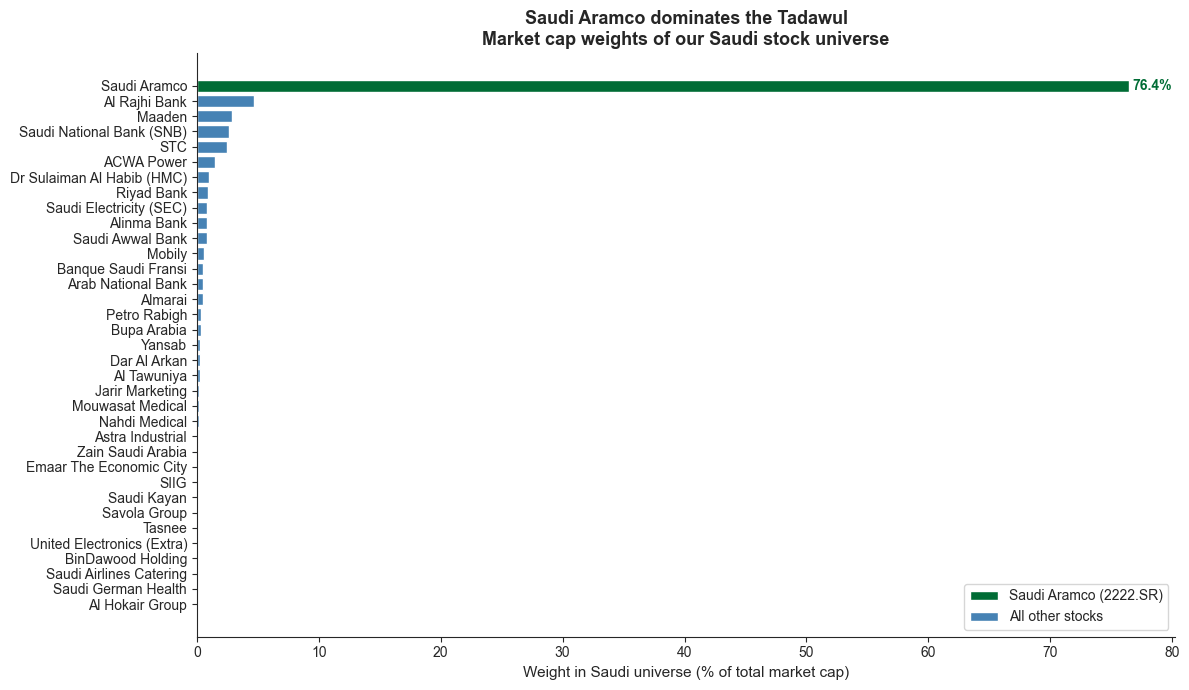

In [66]:
# ── Fetch market cap for every stock in our universe ─────────────────────────
# yf.Ticker().fast_info['market_cap'] returns the current market capitalisation in SAR
# We loop through all tickers; any that fail (e.g. illiquid stocks) are recorded as NaN

print("Fetching market caps... (this may take ~30 seconds)")
market_caps = {}
for ticker in constituents_df['ticker']:
    try:
        market_caps[ticker] = yf.Ticker(ticker).fast_info['market_cap']
    except Exception:
        market_caps[ticker] = None

mcap_series = (
    pd.Series(market_caps, name='market_cap')
    .dropna()
    .sort_values(ascending=False)
)

# ── Compute each stock's weight as % of our universe's total market cap ───────
total_mcap   = mcap_series.sum()
weight_pct   = (mcap_series / total_mcap * 100).round(2)

aramco_weight = weight_pct['2222.SR']
print(f"\nAramco weight in our Saudi universe: {aramco_weight:.1f}%")
print(f"All other {len(weight_pct) - 1} stocks combined:  {100 - aramco_weight:.1f}%")
print(f"\nFor comparison: Apple's weight in the S&P 500 is ~7%")

# ── Build a display DataFrame ─────────────────────────────────────────────────
weight_df = (
    weight_pct
    .rename('weight_%')
    .reset_index()
    .rename(columns={'index': 'ticker'})
    .merge(constituents_df[['ticker', 'company', 'sector']], on='ticker')
)

# ── Bar chart: weight of every stock, Aramco highlighted ─────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#006C35' if t == '2222.SR' else 'steelblue'   # Saudi green for Aramco
          for t in weight_df['ticker']]

ax.barh(weight_df['company'], weight_df['weight_%'], color=colors)

# Label Aramco's bar with its exact weight
aramco_row = weight_df[weight_df['ticker'] == '2222.SR'].iloc[0]
ax.text(
    aramco_row['weight_%'] + 0.3,
    weight_df[weight_df['ticker'] == '2222.SR'].index[0],
    f"{aramco_row['weight_%']:.1f}%",
    va='center', fontweight='bold', color='#006C35'
)

ax.set_xlabel('Weight in Saudi universe (% of total market cap)', fontsize=11)
ax.set_title(
    'Saudi Aramco dominates the Tadawul\n'
    'Market cap weights of our Saudi stock universe',
    fontsize=13, fontweight='bold'
)
ax.invert_yaxis()  # largest weight at the top

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#006C35', label='Saudi Aramco (2222.SR)'),
    Patch(facecolor='steelblue', label='All other stocks'),
]
ax.legend(handles=legend_elements, loc='lower right')

sns.despine()
plt.tight_layout()
plt.show()

## 6. Regression Function

For each stock we fit the **CAPM regression**:

$$\text{Stock Return}_t = \alpha + \beta \times \text{TASI Return}_t + \varepsilon_t$$

| Output | What it measures |
|--------|------------------|
| **Alpha (α)** | Return when the market return is 0% — persistent alpha > 0 means the stock outperforms on a risk-adjusted basis |
| **Beta (β)** | Slope: how many percentage points the stock moves per 1 pp move in TASI |
| **R-squared** | Fraction of the stock's variance explained by the market. High R² = tightly linked to the index; low R² = driven by company-specific factors |
| **Residual SE** | Average size of the leftover errors — captures idiosyncratic (stock-specific) risk |

**Data quality gate:** We require at least **35 monthly observations (~3 years)** for a reliable estimate. Stocks listed more recently (recent IPOs) are excluded to avoid noisy betas from thin data.

In [67]:
def calculate_regression_stats(stock_data, market_return_col):
    """
    Fit OLS: Stock Return ~ TASI Return. Return alpha, beta, R², residual SE.

    Parameters
    ----------
    stock_data        : pd.Series   — monthly returns for a single stock
    market_return_col : pd.DataFrame — monthly TASI returns (single column)

    Returns
    -------
    pd.Series with keys: Alpha, Beta, R_Squared, Residual_SE
    Returns NaN for all if fewer than 35 valid paired observations.
    """
    # ── Align and clean data ──────────────────────────────────────────────────
    # Combine the stock series and TASI column on their shared date index
    # dropna() removes months where either series has a missing value
    regression_df = pd.concat([stock_data, market_return_col], axis=1).dropna()

    # ── Data quality gate ─────────────────────────────────────────────────────
    if len(regression_df) < 35:
        return pd.Series({'Alpha': np.nan, 'Beta': np.nan,
                          'R_Squared': np.nan, 'Residual_SE': np.nan})

    # ── Build and fit the OLS model ───────────────────────────────────────────
    # Q("2222.SR") is statsmodels syntax for quoting a column name that contains
    # special characters (the dot and digits in Saudi ticker codes break the
    # formula parser without quoting)
    model_formula = f'Q("{stock_data.name}") ~ TASI_Return'
    model = smf.ols(formula=model_formula, data=regression_df).fit()

    # ── Extract key statistics ────────────────────────────────────────────────
    return pd.Series({
        'Alpha':       model.params.get('Intercept', np.nan),   # monthly alpha
        'Beta':        model.params.get('TASI_Return', np.nan), # market sensitivity
        'R_Squared':   model.rsquared,                          # variance explained by market
        'Residual_SE': np.sqrt(model.mse_resid)                 # idiosyncratic risk
    })

print("Regression function defined.")

Regression function defined.


## 7. Run Regressions for All Stocks

We use **`.apply()`** to run `calculate_regression_stats` on every stock column of the returns DataFrame — one regression per company in a single pandas operation.

```
monthly_returns_wide  (~60 rows × ~38 cols)
       │
       ▼  .drop(columns='TASI_Return')         → remove TASI so we don't regress it on itself
       │
       ▼  .apply(calculate_regression_stats)   → returns a 4-row × N_stocks DataFrame
       │
       ▼  .T                                   → transpose → N_stocks rows × 4 cols
       │
       ▼  .merge(constituents_df)              → add company name and sector label
       │
       ▼  .dropna(subset=['Beta'])             → drop stocks where regression couldn't run
regression_results  ✓
```

In [68]:
print("Fitting regressions...")
start_time = time.perf_counter()  # start timer

regression_results = (
    monthly_returns_wide.drop(columns='TASI_Return')  # don't regress TASI on itself
    .apply(
        calculate_regression_stats,
        market_return_col=monthly_returns_wide[['TASI_Return']]  # pass TASI as a keyword arg
    )                                                # result: 4 rows × N_stocks cols
    .T                                               # transpose so stocks are rows
    .merge(
        constituents_df.set_index('ticker'),         # set ticker as the index for alignment
        left_index=True,
        right_index=True                             # join on the ticker symbol
    )
    .dropna(subset=['Beta'])                         # remove stocks where regression failed
)

duration = time.perf_counter() - start_time
print(f"Fitted {len(regression_results)} regressions in {duration:.1f} seconds.")
regression_results.round(3).head(10)

Fitting regressions...
Fitted 35 regressions in 0.1 seconds.


,Alpha,Beta,R_Squared,Residual_SE,company,sector
Ticker,,,,,,
1010.SR,0.006,1.145,0.490,0.056,Riyad Bank,Financials
1050.SR,0.005,0.912,0.360,0.058,Banque Saudi Fransi,Financials
1060.SR,0.005,0.982,0.461,0.051,Saudi Awwal Bank,Financials
1080.SR,0.008,0.922,0.322,0.064,Arab National Bank,Financials
1120.SR,0.011,1.284,0.684,0.042,Al Rajhi Bank,Financials
1150.SR,0.012,1.237,0.641,0.044,Alinma Bank,Financials
1180.SR,0.004,1.059,0.530,0.048,Saudi National Bank (SNB),Financials
1211.SR,0.023,1.666,0.446,0.089,Maaden,Materials
1212.SR,0.029,1.182,0.279,0.091,Astra Industrial,Industrials


## 8. Beta Distribution by Sector — Boxplot

A **boxplot** shows the distribution of beta within each Tadawul sector:

```
     ┌────────────────┐
─────┤25%  median  75%├─────   whiskers extend to ~1.5× IQR
     └────────────────┘
```

| Feature | What it tells you |
|---------|------------------|
| Vertical line inside box | Median beta for the sector |
| Box width | Interquartile range — middle 50% of betas in that sector |
| Whiskers | Range of typical betas |
| Dots beyond whiskers | Unusually high or low beta stocks |

Sectors are ordered from **highest to lowest mean beta**. The **red dashed line at Beta = 1** marks the market reference point.

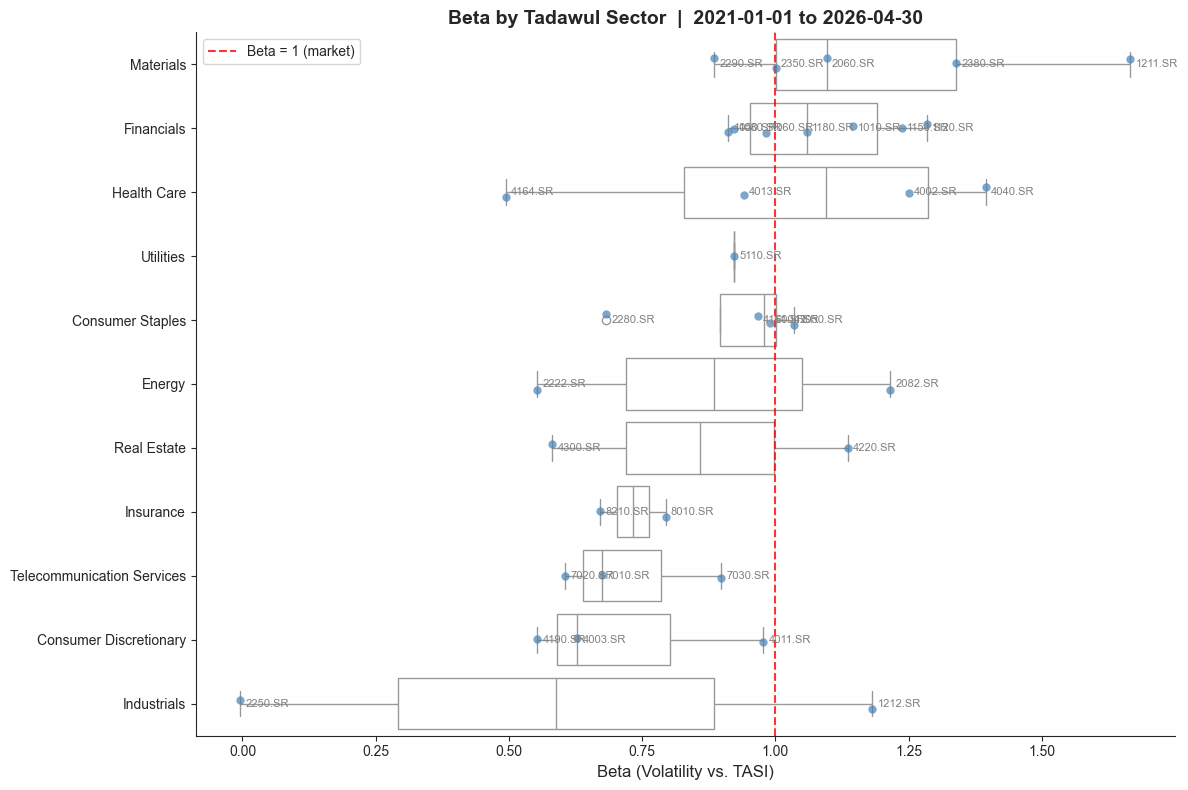

In [69]:
# Sort sectors by mean beta (descending) so the most market-sensitive appear at the top
sector_order = (
    regression_results
    .groupby('sector')['Beta']
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.set_style('ticks')
fig, ax = plt.subplots(figsize=(12, 8))

sns.boxplot(
    data=regression_results,
    x='Beta',
    y='sector',
    order=sector_order,
    color='white',
    ax=ax
)

# Overlay individual stock dots so we can see where each company sits
sns.stripplot(
    data=regression_results,
    x='Beta',
    y='sector',
    order=sector_order,
    color='steelblue',
    size=6,
    alpha=0.7,
    jitter=True,
    ax=ax
)

# Annotate each dot with the company ticker for easy identification
for _, row in regression_results.iterrows():
    ax.text(
        row['Beta'] + 0.01,                  # slightly to the right of the dot
        list(sector_order).index(row['sector']),  # y position by sector index
        row.name,                            # ticker label (e.g. '2222.SR')
        fontsize=8, va='center', color='gray'
    )

# Red dashed reference line at Beta = 1 (= the market itself)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.8, label='Beta = 1 (market)')

ax.set_title(
    f'Beta by Tadawul Sector  |  {start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Beta (Volatility vs. TASI)', fontsize=12)
ax.set_ylabel('')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 9. Summary Statistics by Sector

The table below aggregates beta across all stocks in each Tadawul sector.

| Column | Meaning |
|--------|--------|
| `count` | Number of stocks with a valid beta estimate |
| `mean` | Average beta for the sector |
| `std` | Standard deviation of betas — high std means wide range of risk profiles within the sector |
| `min` / `max` | Most defensive and most aggressive stock in the sector |

Sorted by mean beta (highest first) — consistent with the boxplot above.

In [70]:
print("--- Beta Summary by Tadawul Sector ---")

beta_summary = (
    regression_results
    .groupby('sector')['Beta']
    .agg(['count', 'mean', 'std', 'min', 'max'])  # five summary stats
    .sort_values('mean', ascending=False)          # highest mean beta at the top
    .round(3)
)
display(beta_summary)

--- Beta Summary by Tadawul Sector ---


,count,mean,std,min,max
sector,,,,,
Materials,5,1.197,0.311,0.885,1.666
Financials,7,1.077,0.149,0.912,1.284
Health Care,4,1.020,0.398,0.494,1.394
Utilities,1,0.923,NaN,0.923,0.923
Consumer Staples,4,0.919,0.160,0.682,1.036
Energy,2,0.884,0.468,0.553,1.215
Real Estate,2,0.858,0.392,0.581,1.135
Insurance,2,0.733,0.086,0.672,0.794
Telecommunication Services,3,0.726,0.153,0.606,0.898


## 10. Most and Least Volatile Stocks

Individual stock highlights — the 10 highest and 10 lowest beta names in our Saudi universe.

**What to look for alongside Beta:**
- **R_Squared** — if a high-beta stock has a low R², most of its volatility is *idiosyncratic* (company-specific), not driven by the market. That is a different kind of risk.
- **Aramco** — given its index dominance, expect its beta to sit very close to 1 and its R² to be among the highest in the universe.

> Stocks with Beta < 1 tend to hold up better during market downturns — historically Utilities, Consumer Staples, and Telecoms.

In [71]:
display_cols = ['Beta', 'Alpha', 'R_Squared', 'company', 'sector']

# ── Top 10 Highest Beta ───────────────────────────────────────────────────────
print("--- Top 10 Highest Beta (Most Volatile) ---")
display(
    regression_results
    .nlargest(10, 'Beta')
    [display_cols]
    .round(3)
)

# ── Top 10 Lowest Beta ────────────────────────────────────────────────────────
print("\n--- Top 10 Lowest Beta (Most Defensive) ---")
display(
    regression_results
    .nsmallest(10, 'Beta')
    [display_cols]
    .round(3)
)

--- Top 10 Highest Beta (Most Volatile) ---


,Beta,Alpha,R_Squared,company,sector
Ticker,,,,,
1211.SR,1.666,0.023,0.446,Maaden,Materials
4040.SR,1.394,-0.009,0.401,Saudi German Health,Health Care
2380.SR,1.339,0.007,0.266,Petro Rabigh,Materials
1120.SR,1.284,0.011,0.684,Al Rajhi Bank,Financials
4002.SR,1.250,-0.001,0.391,Mouwasat Medical,Health Care
1150.SR,1.237,0.012,0.641,Alinma Bank,Financials
2082.SR,1.215,0.020,0.219,ACWA Power,Energy
1212.SR,1.182,0.029,0.279,Astra Industrial,Industrials
1010.SR,1.145,0.006,0.490,Riyad Bank,Financials



--- Top 10 Lowest Beta (Most Defensive) ---


,Beta,Alpha,R_Squared,company,sector
Ticker,,,,,
2250.SR,-0.004,0.021,0.000,SIIG,Industrials
4164.SR,0.494,-0.003,0.188,Nahdi Medical,Health Care
4190.SR,0.553,0.001,0.238,Jarir Marketing,Consumer Discretionary
2222.SR,0.553,0.001,0.358,Saudi Aramco,Energy
4300.SR,0.581,0.012,0.100,Dar Al Arkan,Real Estate
7020.SR,0.606,0.015,0.246,Mobily,Telecommunication Services
4003.SR,0.628,0.005,0.254,United Electronics (Extra),Consumer Discretionary
8210.SR,0.672,0.013,0.148,Bupa Arabia,Insurance
7010.SR,0.674,0.002,0.403,STC,Telecommunication Services


## 11. Beta Distribution — Histogram

A histogram shows the **full spread** of beta estimates across all Saudi stocks in our universe.

**What to look for:**
- Is the distribution centred near 1? (Expected — most stocks track the market to some degree)
- How wide is the spread? A narrow distribution means risk profiles are fairly homogeneous across the Saudi market
- Are there stocks with Beta > 2 or Beta < 0? (Worth examining individually)

**Saudi-specific note:** With Aramco dominating the TASI, the distribution may cluster more tightly around 1 than you would see in a more diversified index like the S&P 500.

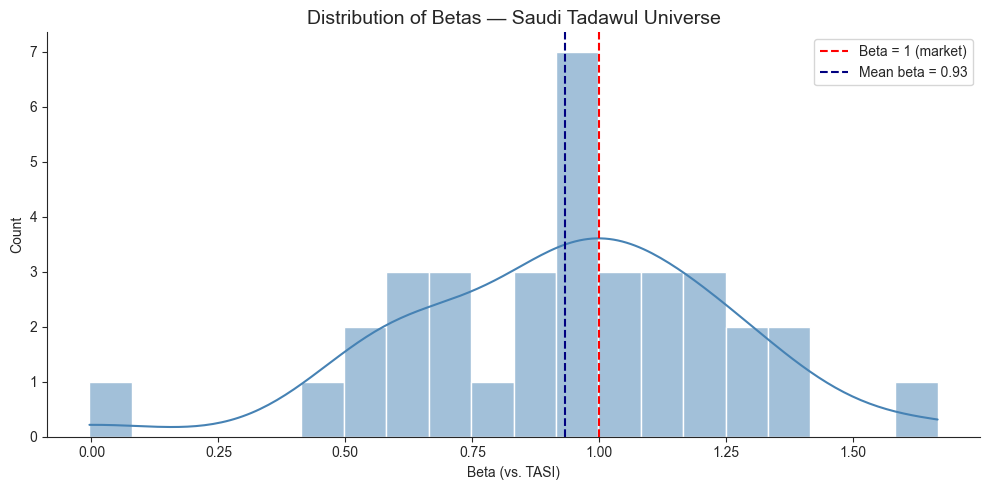

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(regression_results['Beta'], bins=20, kde=True, ax=ax, color='steelblue')

# Reference lines
ax.axvline(1, color='red', linestyle='--', linewidth=1.5, label='Beta = 1 (market)')
ax.axvline(
    regression_results['Beta'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f"Mean beta = {regression_results['Beta'].mean():.2f}"
)

ax.set_title('Distribution of Betas — Saudi Tadawul Universe', fontsize=14)
ax.set_xlabel('Beta (vs. TASI)')
ax.set_ylabel('Count')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 13. Extension — Rolling Beta

A single beta estimated over the full 5-year window is a **static average**. Rolling beta shows how that sensitivity to the market has changed month by month — revealing regime shifts, crisis spikes, and stocks that have become more or less correlated with the TASI over time.

**Window choice — 24 months:**
- Shorter windows (12 months) react faster but are very noisy
- Longer windows (36 months) are smoother but lag real structural changes
- 24 months is the standard academic compromise for monthly data

**What to look for:**
- A rising beta means the stock is becoming more tightly linked to the market cycle
- A falling beta means it is becoming more idiosyncratic (company-specific drivers dominating)
- Sharp spikes often coincide with market-wide crises when all correlations jump temporarily

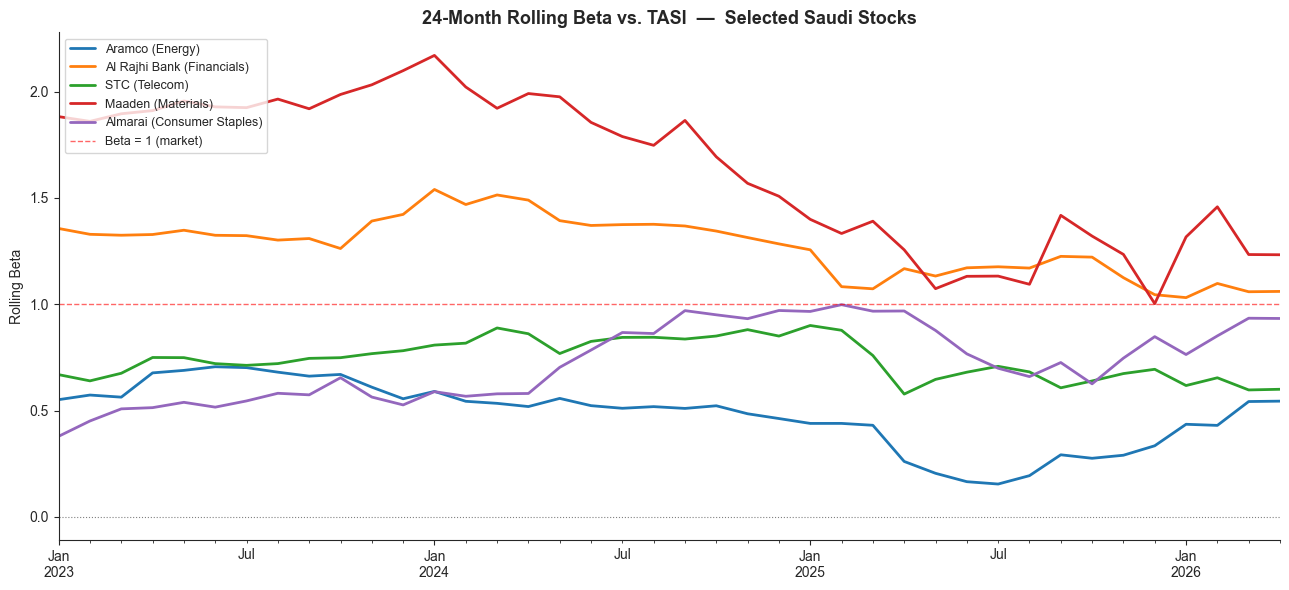

In [73]:
# ── Select representative stocks spanning different sectors ───────────────────
selected = {
    '2222.SR': 'Aramco (Energy)',
    '1120.SR': 'Al Rajhi Bank (Financials)',
    '7010.SR': 'STC (Telecom)',
    '1211.SR': 'Maaden (Materials)',
    '2280.SR': 'Almarai (Consumer Staples)',
}

WINDOW = 24  # rolling window in months

def rolling_beta(stock_series, market_series, window):
    """
    Compute rolling OLS beta using numpy (faster than statsmodels in a loop).
    Each beta is estimated on the window ending at that date.
    """
    aligned = pd.concat([stock_series, market_series], axis=1).dropna()
    betas, dates = [], []
    for i in range(window, len(aligned) + 1):
        chunk = aligned.iloc[i - window:i]
        y = chunk.iloc[:, 0].values
        x = chunk.iloc[:, 1].values
        X = np.column_stack([np.ones(len(x)), x])  # design matrix: [1, market_return]
        beta = np.linalg.lstsq(X, y, rcond=None)[0][1]  # slope coefficient = beta
        betas.append(beta)
        dates.append(chunk.index[-1])
    return pd.Series(betas, index=pd.DatetimeIndex(dates))

# ── Compute rolling beta for each selected stock ──────────────────────────────
market = monthly_returns_wide['TASI_Return']
rolling_beta_df = pd.DataFrame({
    label: rolling_beta(monthly_returns_wide[ticker], market, WINDOW)
    for ticker, label in selected.items()
    if ticker in monthly_returns_wide.columns
})

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

for col in rolling_beta_df.columns:
    rolling_beta_df[col].plot(ax=ax, linewidth=2, label=col)

ax.axhline(1, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Beta = 1 (market)')
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)

ax.set_title(
    f'{WINDOW}-Month Rolling Beta vs. TASI  —  Selected Saudi Stocks',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Rolling Beta')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 14. Extension — Market-Cap Weighted Index Excluding Aramco

We saw in Section 5 that Aramco's free-float weight in the TASI is much smaller than its total market cap suggests. The question here is sharper: **if we build a market-cap weighted index from our universe but simply leave Aramco out, how do betas change?**

We reuse the market caps fetched in Section 5, drop Aramco, renormalise the remaining weights to sum to 1, and compute a monthly return series for this **MCW ex-Aramco** index. Then we re-run every regression and compare.

Because the weighting methodology is unchanged (market-cap weighted in both cases), any shift in beta is cleanly attributable to **Aramco's removal** — not to a change in how the index is constructed.

**How to read the chart:**
- Points **on the diagonal**: beta is unaffected by removing Aramco
- Points **above the diagonal**: the stock is more correlated with the non-Aramco market than with the full TASI
- Points **below the diagonal**: the stock's TASI beta was partly driven by co-movement with Aramco; without it, the measured sensitivity falls

In [74]:
import plotly.express as px
import plotly.graph_objects as go

# ── Helper: numpy-based OLS returning (beta, R²) ─────────────────────────────
# Reused in Section 15 (Brent) as well
def ols_beta_r2(y_series, x_series, min_obs=35):
    """OLS slope and R² for y ~ x. Returns (nan, nan) if insufficient data."""
    aligned = pd.concat([y_series, x_series], axis=1).dropna()
    if len(aligned) < min_obs:
        return np.nan, np.nan
    y = aligned.iloc[:, 0].values
    x = aligned.iloc[:, 1].values
    X = np.column_stack([np.ones(len(x)), x])
    coeffs = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat  = X @ coeffs
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return coeffs[1], r2  # slope = beta, r²

# ── Build market-cap weighted index excluding Aramco ──────────────────────────
mcap_ex_aramco = mcap_series.drop('2222.SR', errors='ignore')
valid = [t for t in mcap_ex_aramco.index if t in monthly_returns_wide.columns]
mcap_ex_aramco = mcap_ex_aramco[valid]
weights = mcap_ex_aramco / mcap_ex_aramco.sum()

print("Market-cap weights (ex-Aramco), top 10:")
print((weights * 100).round(2).sort_values(ascending=False).head(10).to_string())

mcw_monthly = (
    monthly_returns_wide[valid]
    .fillna(0)
    .dot(weights)
)
mcw_monthly.name = 'MCW_Return'

# ── Re-run regressions for all stocks vs. both benchmarks ────────────────────
info_df = constituents_df.set_index('ticker')
stock_cols = [c for c in monthly_returns_wide.columns if c != 'TASI_Return']

rows = []
for ticker in stock_cols:
    stock = monthly_returns_wide[ticker]
    beta_tasi, _ = ols_beta_r2(stock, monthly_returns_wide['TASI_Return'])
    beta_mcw,  _ = ols_beta_r2(stock, mcw_monthly)
    rows.append({
        'ticker':    ticker,
        'company':   info_df.loc[ticker, 'company'] if ticker in info_df.index else ticker,
        'sector':    info_df.loc[ticker, 'sector']  if ticker in info_df.index else '',
        'beta_tasi': beta_tasi,
        'beta_mcw':  beta_mcw,
    })

compare_betas = pd.DataFrame(rows).dropna()
compare_betas['delta'] = compare_betas['beta_mcw'] - compare_betas['beta_tasi']
compare_betas = compare_betas.round(3)

# ── Interactive scatter: hover to identify each company ───────────────────────
lo = float(compare_betas[['beta_tasi', 'beta_mcw']].min().min()) - 0.05
hi = float(compare_betas[['beta_tasi', 'beta_mcw']].max().max()) + 0.05

fig = px.scatter(
    compare_betas,
    x='beta_tasi',
    y='beta_mcw',
    color='sector',
    hover_name='company',
    hover_data={
        'sector':    False,
        'beta_tasi': ':.3f',
        'beta_mcw':  ':.3f',
        'delta':     ':.3f',
    },
    labels={
        'beta_tasi': 'Beta vs. TASI (original)',
        'beta_mcw':  'Beta vs. MCW Index ex-Aramco',
    },
    title='Effect of removing Aramco from the benchmark<br>'
          '<sup>Market-cap weighted index — hover over any dot to identify the company</sup>',
    height=680,
    template='plotly_white',
)

# y = x diagonal reference line
fig.add_trace(go.Scatter(
    x=[lo, hi], y=[lo, hi],
    mode='lines',
    line=dict(dash='dash', color='gray', width=1),
    name='No change (y = x)',
))

fig.update_traces(marker=dict(size=10, opacity=0.85), selector=dict(mode='markers'))
fig.update_layout(legend_title_text='Sector')
fig.show()

# ── Summary table: biggest movers ─────────────────────────────────────────────
print("\nStocks whose beta changed most when Aramco is removed from the benchmark:")
display(
    compare_betas
    .reindex(compare_betas['delta'].abs().sort_values(ascending=False).index)
    [['company', 'sector', 'beta_tasi', 'beta_mcw', 'delta']]
    .head(10)
)

Market-cap weights (ex-Aramco), top 10:
1120.SR    19.93
1211.SR    12.35
1180.SR    11.28
7010.SR    10.50
2082.SR     6.27
4013.SR     4.18
1010.SR     4.01
5110.SR     3.57
1150.SR     3.53
1060.SR     3.39



Stocks whose beta changed most when Aramco is removed from the benchmark:


,company,sector,beta_tasi,beta_mcw,delta
9,Savola Group,Consumer Staples,1.036,0.750,-0.286
17,Petro Rabigh,Materials,1.339,1.107,-0.232
8,Astra Industrial,Industrials,1.182,0.953,-0.228
26,Emaar The Economic City,Real Estate,1.135,0.925,-0.211
16,Saudi Kayan,Materials,1.000,0.791,-0.210
15,Yansab,Materials,0.885,0.687,-0.198
10,Tasnee,Materials,1.096,0.907,-0.189
20,Al Hokair Group,Consumer Discretionary,0.977,0.811,-0.166
23,BinDawood Holding,Consumer Staples,0.967,0.813,-0.154
22,Saudi German Health,Health Care,1.394,1.242,-0.153


**Why do almost all betas fall when Aramco is removed?**

Once Aramco is excluded, the MCW index is dominated by **Al Rajhi Bank and SNB** — the two largest remaining free-float companies. The benchmark has effectively shifted from a mixed oil-and-bank index to a purer **domestic financial-cycle index**.

Aramco moves primarily with the global oil price, which has low correlation with Saudi bank returns. When it is part of the benchmark, it adds volatility that is largely unrelated to the domestic economy — making the TASI a somewhat noisier benchmark. Most stocks have moderate-to-low correlation with oil prices, so they look more correlated with the TASI (which averages oil + bank movements) than with a benchmark that is purely bank-driven.

Once that oil noise is removed and the benchmark is a cleaner signal of the Saudi domestic economy, most stocks appear *less* sensitive to it — hence lower betas across the board.

The stocks that **do not fall** (or rise) when Aramco is removed are those whose returns are genuinely driven by the same domestic-economy cycle as Al Rajhi and SNB — for example, consumer discretionary names and real estate developers that benefit from the same government-spending and credit-expansion cycles as the banks.

## 15. Extension — Cross-Market Beta vs. Brent Crude

So far we have measured each stock's sensitivity to the **Saudi market** (TASI). But Saudi Arabia is an oil economy, and many companies — even those not in the energy sector — may have returns that move with the **global oil price**.

We now regress each stock against **Brent crude futures (`BZ=F`)** monthly returns to answer: *which Saudi stocks are oil-price stocks, and which are genuine domestic-economy stocks?*

**What to expect:**
- Energy and petrochemicals: high Brent beta — their revenues move directly with the oil price
- Banks: moderate Brent beta — Saudi bank profits expand in oil boom cycles (government spending drives credit demand)
- Healthcare, telecoms, consumer staples: low Brent beta — demand for hospitals, phone plans, and groceries does not depend on the oil price

**Currency note:** Brent is quoted in USD; Saudi stocks trade in SAR. Since the SAR has been pegged to the USD at 3.75 since 1986, there is effectively no FX effect on these regressions.

In [75]:
# ── Download Brent crude futures ──────────────────────────────────────────────
print("Downloading Brent crude futures (BZ=F)...")
brent_raw = yf.download('BZ=F', start=start_date, end=end_date,
                        auto_adjust=False, progress=False)['Adj Close']

# Newer yfinance versions return a single-ticker download as a DataFrame;
# squeeze() converts it to a Series regardless of which version is installed
if isinstance(brent_raw, pd.DataFrame):
    brent_raw = brent_raw.squeeze()

brent_monthly = (
    brent_raw
    .resample('ME').last()
    .pct_change()
    .iloc[1:]
)
brent_monthly.name = 'Brent_Return'
print(f"Brent monthly returns: {int(brent_monthly.notna().sum())} months with data")

# ── Regress every stock against Brent ────────────────────────────────────────
# Uses ols_beta_r2() defined in Section 14
all_stock_cols = [c for c in monthly_returns_wide.columns if c != 'TASI_Return']

brent_rows = []
for ticker in all_stock_cols:
    beta_b, r2_b = ols_beta_r2(monthly_returns_wide[ticker], brent_monthly)
    brent_rows.append({
        'ticker':     ticker,
        'company':    info_df.loc[ticker, 'company'] if ticker in info_df.index else ticker,
        'sector':     info_df.loc[ticker, 'sector']  if ticker in info_df.index else 'Unknown',
        'beta_brent': beta_b,
        'r2_brent':   r2_b,
    })

brent_betas = (
    pd.DataFrame(brent_rows)
    .dropna()
    .sort_values('beta_brent', ascending=True)
    .round(3)
)

# ── Interactive bar chart: Brent beta per stock, coloured by sector ───────────
fig = px.bar(
    brent_betas,
    x='beta_brent',
    y='company',
    color='sector',
    orientation='h',
    hover_name='company',
    hover_data={
        'company':    False,
        'sector':     False,
        'beta_brent': ':.3f',
        'r2_brent':   ':.3f',
    },
    labels={'beta_brent': 'Beta vs. Brent Crude (BZ=F)', 'company': ''},
    title='Oil Price Sensitivity of Saudi Stocks<br>'
          '<sup>Beta vs. Brent Crude monthly returns — hover for R²</sup>',
    height=750,
    template='plotly_white',
)

fig.add_vline(x=0, line_color='black', line_width=0.8)
fig.update_layout(legend_title_text='Sector', yaxis={'categoryorder': 'total ascending'})
fig.show()

# ── Sector summary table ──────────────────────────────────────────────────────
print("\nMean Brent beta by sector (sorted highest to lowest):")
display(
    brent_betas.groupby('sector')['beta_brent']
    .agg(['count', 'mean', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .round(3)
)

Brent monthly returns: 63 months with data



Mean Brent beta by sector (sorted highest to lowest):


,count,mean,min,max
sector,,,,
Materials,5,0.345,0.119,0.568
Utilities,1,0.312,0.312,0.312
Health Care,4,0.233,0.122,0.399
Industrials,2,0.200,0.162,0.238
Energy,2,0.169,0.135,0.204
Consumer Staples,4,0.162,0.048,0.274
Financials,7,0.138,0.071,0.199
Real Estate,2,0.076,-0.029,0.181
Consumer Discretionary,3,0.055,-0.033,0.142


### Further Reading

- [Saudi Exchange (Tadawul) official site](https://www.saudiexchange.sa)
- [yfinance documentation](https://ranaroussi.github.io/yfinance/)
- [CAPM — Investopedia](https://www.investopedia.com/terms/c/capm.asp)
- [statsmodels OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)